# Edgar demo: symbolic discovery on a toy dataset

This notebook walks through a minimal end-to-end workflow with `Edgar`.
We generate a synthetic dataset with a known symbolic form, define simple
seed programs/parameter estimators, preview the prompts/diagnostics, and
show how to launch the engine and inspect the resulting census snapshots.

> **Note:** Running the full engine still requires valid Google GenAI API
> credentials (\`GOOGLE_API_KEY\`). The cell that actually executes the
> agent is wrapped in a try/except so the rest of the demo can be explored
> even without credentials.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import inspect

from entities import Program
from hypothesis_engine import Edgar, load_program_snapshots
import utils, tuning_curves_project


gpu
[CudaDevice(id=0)]


In [3]:
rng = np.random.default_rng(0)
theta = np.linspace(0, 2 * np.pi, 200)

def ground_truth(theta, amplitude1=1.0, amplitude2=0.5, bias=0.3, freq=2.0, phase=0.0):
    return bias + amplitude1 * np.cos(freq * theta - phase) + amplitude2 * np.cos(freq * (theta -phase)**2)

n_units = 50
X = np.tile(theta, (n_units, 1))
signals = []
for _ in range(n_units):
    amp1 = abs(0.9 + 0.25 * rng.standard_normal())
    amp2 = abs(0.5 + 0.1 * rng.standard_normal())
    bias = 0.2 * rng.random()
    freq = 1.0 + rng.integers(0, 4)
    phase = rng.uniform(0, np.pi)
    clean = ground_truth(theta, amplitude1=amp1, amplitude2=amp2, bias=bias, freq=freq, phase=phase)
    noisy = clean + 0.1 * rng.standard_normal(theta.shape)
    signals.append(noisy)
Y = np.asarray(signals)
print(X.shape, Y.shape)


(50, 200) (50, 200)


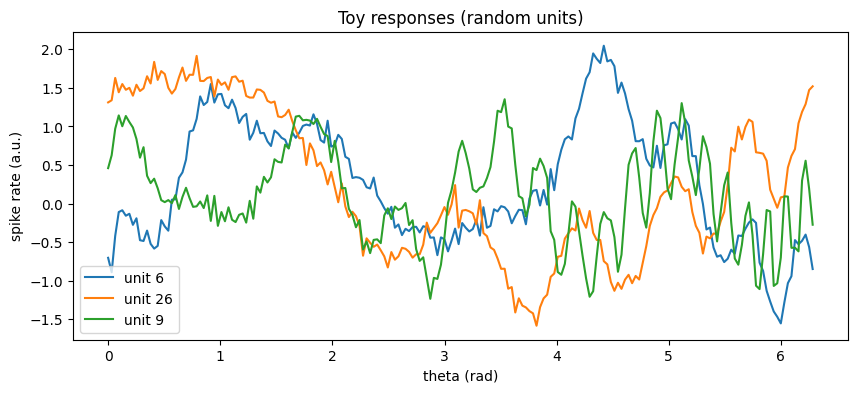

In [4]:
plt.figure(figsize=(10, 4))
random_units = rng.choice(Y.shape[0], size=3, replace=False)  # Select 3 random units
for unit in random_units:
    plt.plot(theta, Y[unit], label=f'unit {unit}')
plt.title('Toy responses (random units)')
plt.xlabel('theta (rad)')
plt.ylabel('spike rate (a.u.)')
plt.legend()
plt.show()


In [5]:
def seed_model_cosine_numpy(theta, A=1.0, B=0.2, phase=0.0):
    theta = np.asarray(theta)
    return B + A * np.cos(theta - phase)

def seed_model_cosine_jax(theta, A=1.0, B=0.2, phase=0.0):
    theta = jnp.asarray(theta)
    return B + A * jnp.cos(theta - phase)

def seed_model_double_cosine_numpy(theta, A1=1.0, A2=0.5, B=0.2, phase=0.0):
    theta = np.asarray(theta)
    return B + A1 * np.cos(theta - phase) + A2 * np.cos(2 * (theta - phase))

def seed_model_double_cosine_jax(theta, A1=1.0, A2=0.5, B=0.2, phase=0.0):
    theta = jnp.asarray(theta)
    return B + A1 * jnp.cos(theta - phase) + A2 * jnp.cos(2 * (theta - phase))

def parameter_estimator_cosine(X, Y):
    """
    X: (n_samples, ), Y: (n_samples, )
    """
    B = np.percentile(Y, 5)
    A = np.max(Y) - B
    # estimate phase by finding theta that gives max response
    theta_max = X[np.argmax(Y)]
    phase = theta_max
    return np.array([A, B, phase])

def parameter_estimator_double_cosine(X, Y):
    """
    X: (n_samples, ), Y: (n_samples, )
    """
    B = np.percentile(Y, 5)
    Y_offset = Y - B
    # estimate phase by finding theta that gives max response
    theta_max = X[np.argmax(Y_offset)]
    phase = theta_max
    # estimate A1 and A2 using Fourier coefficients
    A1 = (2 / len(X)) * np.sum(Y_offset * np.cos(X - phase))
    A2 = (2 / len(X)) * np.sum(Y_offset * np.cos(2 * (X - phase)))
    return np.array([A1, A2, B, phase])
    

In [6]:
agent = Edgar(
    n_generations=1,
    use_image_feedback=False,
    seed_functions_numpy=[seed_model_cosine_numpy,
                           seed_model_double_cosine_numpy],
    seed_functions_jax=[seed_model_cosine_jax,
                        seed_model_double_cosine_jax],
    seed_parameter_estimators=[parameter_estimator_cosine,
                              parameter_estimator_double_cosine],
    use_large_every=None,
)
await agent.run_async(jnp.asarray(X), jnp.asarray(Y))
print('Run finished, snapshots:', len(agent.snapshots_))

Base directory: /home/reilly/ai_scientist_project/program_databases
Created folder: /home/reilly/ai_scientist_project/program_databases/12-15/23-51-29
Created image feedback folder: None
step   50  loss 26.1615
step  100  loss 22.6531
step  150  loss 19.5662
step  200  loss 16.9281
step  250  loss 14.7188
step  300  loss 12.8885
step  350  loss 11.3751
step  400  loss 10.1174
step  450  loss 9.0617
step  500  loss 8.1649
step  550  loss 7.3939
step  600  loss 6.7236
step  650  loss 6.1356
step  700  loss 5.6163
step  750  loss 5.1553
step  800  loss 4.7447
step  850  loss 4.3783
step  900  loss 4.0509
step  950  loss 3.7583
step 1000  loss 3.4968
params optimized. Loss: 3.4968
Time taken for optimization: 2.8741 seconds
Initial program 1 loss: 3.91
step   50  loss 9.9635
step  100  loss 9.0132
step  150  loss 8.0197
step  200  loss 7.0921
step  250  loss 6.2786
step  300  loss 5.5781
step  350  loss 4.9758
step  400  loss 4.4580
step  450  loss 4.0142
step  500  loss 3.6357
step  550  

Hypothesis Engine generations:   0%|          | 0/1 [00:00<?, ?it/s]

Creating 48 new programs... Model: gemini-2.0-flash, mode: explore, temperature: 2.00
Error in GenAI async call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
Error in GenAI async call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
Error in GenAI async call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
Error in GenAI async call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
Error in GenAI async call: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
Error in GenAI async call: 429 RESOURCE_EXHAUSTED. {'error': {'c

<string>:16: RuntimeWarning: invalid value encountered in log


step   50  loss 8.0044
step  100  loss 7.2591
step  150  loss 6.5749
step  200  loss 5.9457
step  250  loss 5.3689
step  300  loss 4.8420
step  350  loss 4.3622
step  400  loss 3.9268
step  450  loss 3.5329
step  500  loss 3.1779
step  550  loss 2.8593
step  600  loss 2.5743
step  650  loss 2.3205
step  700  loss 2.0956
step  750  loss 1.8970
step  800  loss 1.7227
step  850  loss 1.5703
step  900  loss 1.4378
step  950  loss 1.3233
step 1000  loss 1.2249
params optimized. Loss: 1.2249
Time taken for optimization: 1.7081 seconds
generation 0, island 6, batch 1, loss: 1.31
--------------------------------------------------
step   50  loss 10.0169
step  100  loss 9.2386
step  150  loss 8.5079
step  200  loss 7.8606
step  250  loss 7.2843
step  300  loss 6.7631
step  350  loss 6.2913
step  400  loss 5.8653
step  450  loss 5.4819
step  500  loss 5.1382
step  550  loss 4.8311
step  600  loss 4.5580
step  650  loss 4.3161
step  700  loss 4.1028
step  750  loss 3.9157
step  800  loss 3.7524
s

Hypothesis Engine generations: 100%|██████████| 1/1 [01:28<00:00, 88.22s/it]


step   50  loss 11.9919
step  100  loss 9.5227
step  150  loss 7.4170
step  200  loss 5.7866
step  250  loss 4.5725
step  300  loss 3.6761
step  350  loss 3.0094
step  400  loss 2.5091
step  450  loss 2.1304
step  500  loss 1.8405
step  550  loss 1.6161
step  600  loss 1.4404
step  650  loss 1.3016
step  700  loss 1.1910
step  750  loss 1.1023
step  800  loss 1.0307
step  850  loss 0.9725
step  900  loss 0.9251
step  950  loss 0.8860
step 1000  loss 0.8538
step 1050  loss 0.8269
step 1100  loss 0.8043
step 1150  loss 0.7852
step 1200  loss 0.7689
step 1250  loss 0.7548
step 1300  loss 0.7426
step 1350  loss 0.7320
step 1400  loss 0.7227
step 1450  loss 0.7144
step 1500  loss 0.7070
step 1550  loss 0.7003
step 1600  loss 0.6942
step 1650  loss 0.6887
step 1700  loss 0.6836
step 1750  loss 0.6789
step 1800  loss 0.6746
step 1850  loss 0.6706
step 1900  loss 0.6670
step 1950  loss 0.6636
step 2000  loss 0.6607
params optimized. Loss: 0.6607
Time taken for optimization: 2.7738 seconds
Test

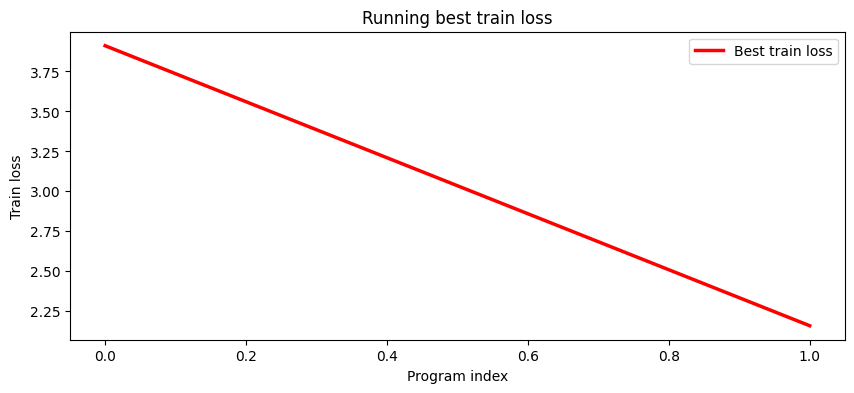

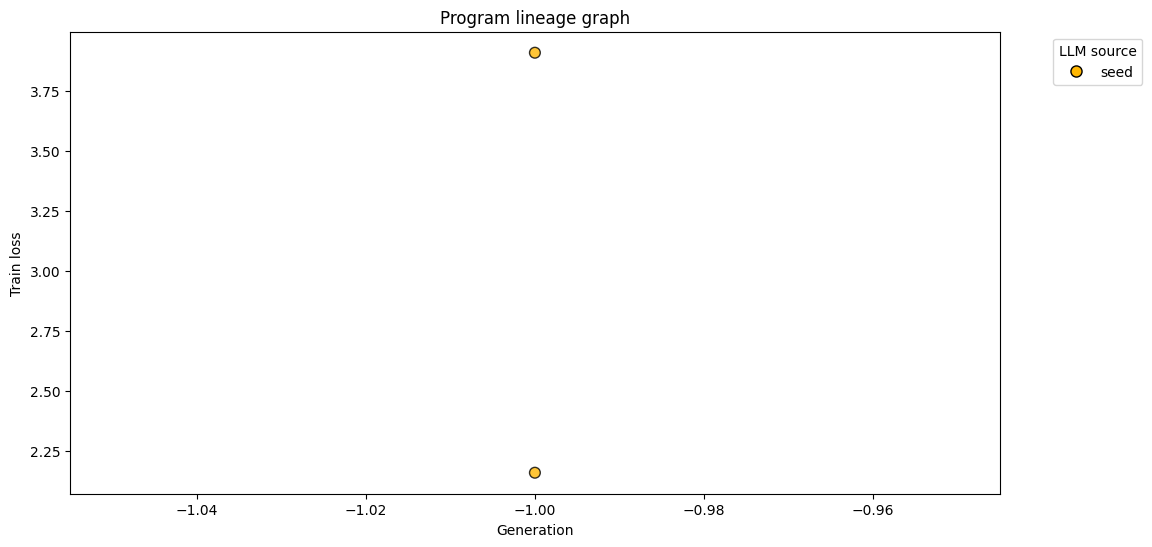

In [ ]:
if agent.snapshots_:
    agent.plot_progress(metric='train')
    plt.show()
    agent.plot_lineage()
    plt.show()
else:
    print('No snapshots are available yet. Once a run completes you can use agent.plot_progress() and agent.plot_lineage().')


In [ ]:
if agent.snapshots_:
    for snap in agent.snapshots_[:3]:
        display(snap.to_dict())
else:
    print('Snapshots can also be reloaded later:')

{'program_index': 0,
 'generation': -1,
 'birth_island': -1,
 'batch_index': 0,
 'train_loss': 3.911133289337158,
 'test_loss': 0.7640085220336914,
 'llm_name': None,
 'parent1_id': None,
 'parent2_id': None,
 'timestamp': 2.9567131996154785,
 'param_count': 3,
 'function_code_string': 'import numpy as np \ndef neuron_model_v1(theta, A=1.0, B=0.2, phase=0.0):\n    theta = np.asarray(theta)\n    return B + A * np.cos(theta - phase)\n',
 'parameter_estimator_code_string': 'import numpy as np \ndef parameter_estimator_v1(X, Y):\n    """\n    X: (n_samples, ), Y: (n_samples, )\n    """\n    B = np.percentile(Y, 5)\n    A = np.max(Y) - B\n    # estimate phase by finding theta that gives max response\n    theta_max = X[np.argmax(Y)]\n    phase = theta_max\n    return np.array([A, B, phase])\n',
 'evaluation_matrix': Array([[2.9821596, 2.735895 , 2.4884706, ..., 3.4672523, 3.2262726,
         2.9821591],
        [2.9821596, 2.735895 , 2.4884706, ..., 3.4672523, 3.2262726,
         2.9821591],

{'program_index': 1,
 'generation': -1,
 'birth_island': -1,
 'batch_index': 1,
 'train_loss': 2.1596744060516357,
 'test_loss': 0.7265734076499939,
 'llm_name': None,
 'parent1_id': None,
 'parent2_id': None,
 'timestamp': 5.212625026702881,
 'param_count': 4,
 'function_code_string': 'import numpy as np \ndef neuron_model_v2(theta, A1=1.0, A2=0.5, B=0.2, phase=0.0):\n    theta = np.asarray(theta)\n    return B + A1 * np.cos(theta - phase) + A2 * np.cos(2 * (theta - phase))\n',
 'parameter_estimator_code_string': 'import numpy as np \ndef parameter_estimator_v2(X, Y):\n    """\n    X: (n_samples, ), Y: (n_samples, )\n    """\n    B = np.percentile(Y, 5)\n    Y_offset = Y - B\n    # estimate phase by finding theta that gives max response\n    theta_max = X[np.argmax(Y_offset)]\n    phase = theta_max\n    # estimate A1 and A2 using Fourier coefficients\n    A1 = (2 / len(X)) * np.sum(Y_offset * np.cos(X - phase))\n    A2 = (2 / len(X)) * np.sum(Y_offset * np.cos(2 * (X - phase)))\n    r